# Hotness Forecasting â€” Autoregressive

**Goal**: Given the last 12 balls of hotness history (+ balls remaining), predict the max hotness in the *next* 6 balls.

**Motivation**: The reactive hotness detector (nb06) fires too late for matches where drama compresses into the last over (e.g. KKR vs LSG â€” notification at ball 119, 1 ball left). A forecasting model can predict upcoming drama and fire earlier.

**Approach**: Start with autoregressive model (hotness predicts future hotness). Hotness already encodes win probability, closeness, and momentum â€” so it's a compressed representation of match state.

Matches:
- **HOT**: DC vs GT (IPL 2026, Apr 8), IND vs PAK (T20 WC 2024, Jun 9)
- **COLD**: RR vs MI (IPL 2026, Apr 7), MI vs RR (IPL 2025, May 1)
- **NEW**: KKR vs LSG (IPL 2026, Apr 9), RCB vs RR (IPL 2026, Apr 10)

In [1]:
import json
import os
import pickle
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, random_split

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

torch.manual_seed(42)
np.random.seed(42)

IPL_DIR    = r'C:\Users\hp\AppData\Local\Temp\cricket_data\ipl_all'
DATA       = '../data/raw/'
MODELS_DIR = Path('../models')
FIG_DIR    = Path('../data/figures/07_hotness_forecast')
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load NN win probability model

In [2]:
class WinProbNet(nn.Module):
    def __init__(self, input_dim=6, hidden_dims=[64, 32, 16]):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(0.1)]
            prev = h
        layers += [nn.Linear(prev, 1), nn.Sigmoid()]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


ckpt = torch.load(MODELS_DIR / 'win_prob_nn.pt', weights_only=False)
wp_model = WinProbNet(input_dim=ckpt['input_dim'], hidden_dims=ckpt['hidden_dims'])
wp_model.load_state_dict(ckpt['model_state_dict'])
wp_model.eval()

WP_FEATURES = ckpt['feature_cols']
X_mean      = ckpt['X_mean']
X_std       = ckpt['X_std']

print('Win prob model loaded:', WP_FEATURES)

Win prob model loaded: ['runs_needed', 'balls_remaining', 'wickets_fallen', 'rrr', 'balls_fraction', 'wickets_fraction']


## Hotness computation pipeline

Same as nb06 â€” parse innings, compute NN win prob, derive closeness + momentum â†’ hotness.

In [3]:
def nn_win_prob(runs_needed, balls_remaining, wickets_fallen):
    rn = np.array(runs_needed, dtype=np.float32)
    br = np.array(balls_remaining, dtype=np.float32)
    wk = np.array(wickets_fallen, dtype=np.float32)
    raw = np.stack([rn, br, wk, rn/np.maximum(br, 1), br/120, wk/10], axis=1)
    X = torch.tensor((raw - X_mean) / X_std)
    with torch.no_grad():
        return wp_model(X).numpy()


def compute_chase_hotness(match_path):
    """Parse a match JSON â†’ return chase DataFrame with hotness, or None if invalid."""
    with open(match_path) as f:
        d = json.load(f)
    if len(d['innings']) < 2:
        return None
    outcome = d['info'].get('outcome', {})
    if 'winner' not in outcome:
        return None

    inn1, inn2 = d['innings'][0], d['innings'][1]

    # Innings 1: get target and total legal balls
    inn1_score, inn1_balls = 0, 0
    for ov in inn1['overs']:
        for b in ov['deliveries']:
            ext = list(b.get('extras', {}).keys())
            inn1_score += b['runs']['total']
            if 'wides' not in ext and 'noballs' not in ext:
                inn1_balls += 1
    target = inn1_score + 1
    total_balls = inn1_balls

    # Innings 2: parse ball by ball
    score, wickets, legal_ball = 0, 0, 0
    rows = []
    for ov in inn2['overs']:
        for b in ov['deliveries']:
            ext = list(b.get('extras', {}).keys())
            is_legal = 'wides' not in ext and 'noballs' not in ext
            score += b['runs']['total']
            if 'wickets' in b:
                wickets += len(b['wickets'])
            if is_legal:
                legal_ball += 1
                rows.append({
                    'legal_ball': legal_ball,
                    'score': score,
                    'wickets_fallen': wickets,
                    'is_wicket': 'wickets' in b,
                })

    if len(rows) < 20:  # skip very short innings
        return None

    df = pd.DataFrame(rows)
    df['runs_needed'] = target - df['score']
    df['balls_remaining'] = (total_balls - df['legal_ball']).clip(lower=0)

    # Win probability
    df['win_prob'] = nn_win_prob(
        df['runs_needed'].values,
        df['balls_remaining'].values,
        df['wickets_fallen'].values
    ).clip(0.02, 0.98)

    # Hotness
    closeness = 1 - 2 * (df['win_prob'] - 0.5).abs()
    df['momentum_6'] = df['win_prob'].diff(6).abs()
    momentum = df['momentum_6'].fillna(0)
    df['hotness'] = (closeness * 0.6 + momentum * 5 * 0.4).clip(0, 1)

    df['target'] = target
    df['total_balls'] = total_balls
    return df


print('Pipeline ready.')

Pipeline ready.


## Compute hotness for all 1,184 IPL matches

In [4]:
all_chases = []
skipped = 0

for fname in sorted(os.listdir(IPL_DIR)):
    if not fname.endswith('.json'):
        continue
    try:
        chase = compute_chase_hotness(os.path.join(IPL_DIR, fname))
        if chase is not None:
            chase['match_id'] = fname
            all_chases.append(chase)
        else:
            skipped += 1
    except Exception:
        skipped += 1

print(f'Parsed: {len(all_chases)} matches | Skipped: {skipped}')

Parsed: 1159 matches | Skipped: 24


## Explore: hotness signal properties

Before building the forecaster, let's understand the signal we're trying to predict.

### Distribution of ball-level hotness across all matches

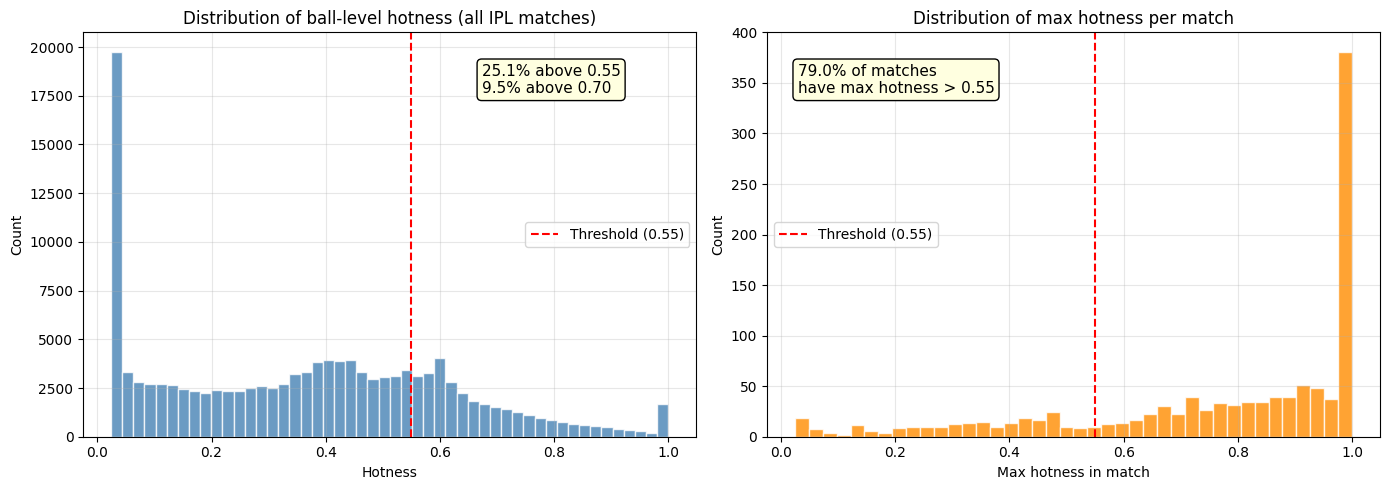

Total balls: 128,511
Mean hotness: 0.364
Median: 0.371


In [5]:
all_hotness = np.concatenate([c['hotness'].values for c in all_chases])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(all_hotness, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0.55, color='red', linestyle='--', label='Threshold (0.55)')
axes[0].set_title('Distribution of ball-level hotness (all IPL matches)')
axes[0].set_xlabel('Hotness')
axes[0].set_ylabel('Count')
axes[0].legend()

pct_above = (all_hotness > 0.55).mean() * 100
pct_above_70 = (all_hotness > 0.70).mean() * 100
axes[0].annotate(f'{pct_above:.1f}% above 0.55\n{pct_above_70:.1f}% above 0.70',
                 xy=(0.65, 0.85), xycoords='axes fraction', fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='lightyellow'))

# Per-match max hotness
max_per_match = [c['hotness'].max() for c in all_chases]
axes[1].hist(max_per_match, bins=40, color='darkorange', edgecolor='white', alpha=0.8)
axes[1].axvline(0.55, color='red', linestyle='--', label='Threshold (0.55)')
axes[1].set_title('Distribution of max hotness per match')
axes[1].set_xlabel('Max hotness in match')
axes[1].set_ylabel('Count')
axes[1].legend()

pct_hot_matches = (np.array(max_per_match) > 0.55).mean() * 100
axes[1].annotate(f'{pct_hot_matches:.1f}% of matches\nhave max hotness > 0.55',
                 xy=(0.05, 0.85), xycoords='axes fraction', fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='lightyellow'))

plt.tight_layout()
plt.savefig(FIG_DIR / 'hotness_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total balls: {len(all_hotness):,}')
print(f'Mean hotness: {all_hotness.mean():.3f}')
print(f'Median: {np.median(all_hotness):.3f}')

### Autocorrelation of hotness

Key question: is hotness at ball `t` predictive of hotness at ball `t+6`? If autocorrelation is high, autoregression should work.

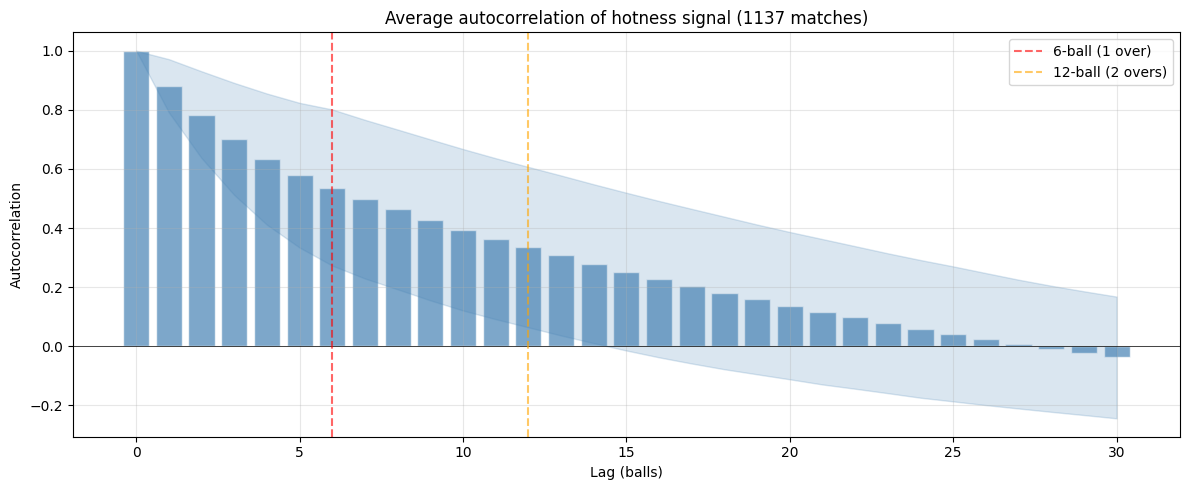

ACF at lag  6: 0.537 Â± 0.264
ACF at lag 12: 0.336 Â± 0.271
ACF at lag 18: 0.181 Â± 0.258


In [6]:
# Compute autocorrelation per match, then average
max_lag = 30
acf_per_match = []

for chase in all_chases:
    h = chase['hotness'].values
    if len(h) < max_lag + 12:
        continue
    h_centered = h - h.mean()
    var = np.var(h)
    if var < 1e-6:
        continue
    acf = [np.mean(h_centered[:-lag] * h_centered[lag:]) / var if lag > 0
           else 1.0
           for lag in range(max_lag + 1)]
    acf_per_match.append(acf)

acf_mean = np.mean(acf_per_match, axis=0)
acf_std  = np.std(acf_per_match, axis=0)

fig, ax = plt.subplots(figsize=(12, 5))
lags = np.arange(max_lag + 1)
ax.bar(lags, acf_mean, color='steelblue', alpha=0.7, edgecolor='white')
ax.fill_between(lags, acf_mean - acf_std, acf_mean + acf_std, alpha=0.2, color='steelblue')
ax.axhline(0, color='black', linewidth=0.5)
ax.axvline(6, color='red', linestyle='--', alpha=0.6, label='6-ball (1 over)')
ax.axvline(12, color='orange', linestyle='--', alpha=0.6, label='12-ball (2 overs)')
ax.set_title(f'Average autocorrelation of hotness signal ({len(acf_per_match)} matches)')
ax.set_xlabel('Lag (balls)')
ax.set_ylabel('Autocorrelation')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'hotness_autocorrelation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'ACF at lag  6: {acf_mean[6]:.3f} Â± {acf_std[6]:.3f}')
print(f'ACF at lag 12: {acf_mean[12]:.3f} Â± {acf_std[12]:.3f}')
print(f'ACF at lag 18: {acf_mean[18]:.3f} Â± {acf_std[18]:.3f}')

### Hotness trajectories: HOT vs COLD examples

Visual intuition for what the forecaster needs to distinguish.

In [7]:
# Load the 6 validation matches
MATCH_FILES = {
    'DC vs GT (HOT)':      'dc_vs_gt_2026-04-08.json',
    'IND vs PAK (HOT)':    'ind_vs_pak_2024-06-09.json',
    'RR vs MI (COLD)':     'rr_vs_mi_2026-04-07.json',
    'MI vs RR (COLD)':     'mi_vs_rr_2025-05-01.json',
    'KKR vs LSG (NEW)':    'kkr_vs_lsg_2026-04-09.json',
    'RCB vs RR (NEW)':     'rcb_vs_rr_2026-04-10.json',
}

val_results = {}
for label, fname in MATCH_FILES.items():
    chase = compute_chase_hotness(DATA + fname)
    val_results[label] = chase
    print(f"{label}: {len(chase)} balls, target={chase['target'].iloc[0]}, "
          f"max_hotness={chase['hotness'].max():.3f}")

DC vs GT (HOT): 120 balls, target=211, max_hotness=1.000
IND vs PAK (HOT): 120 balls, target=120, max_hotness=0.935
RR vs MI (COLD): 66 balls, target=151, max_hotness=0.442
MI vs RR (COLD): 97 balls, target=218, max_hotness=0.319
KKR vs LSG (NEW): 120 balls, target=182, max_hotness=1.000
RCB vs RR (NEW): 108 balls, target=202, max_hotness=0.950


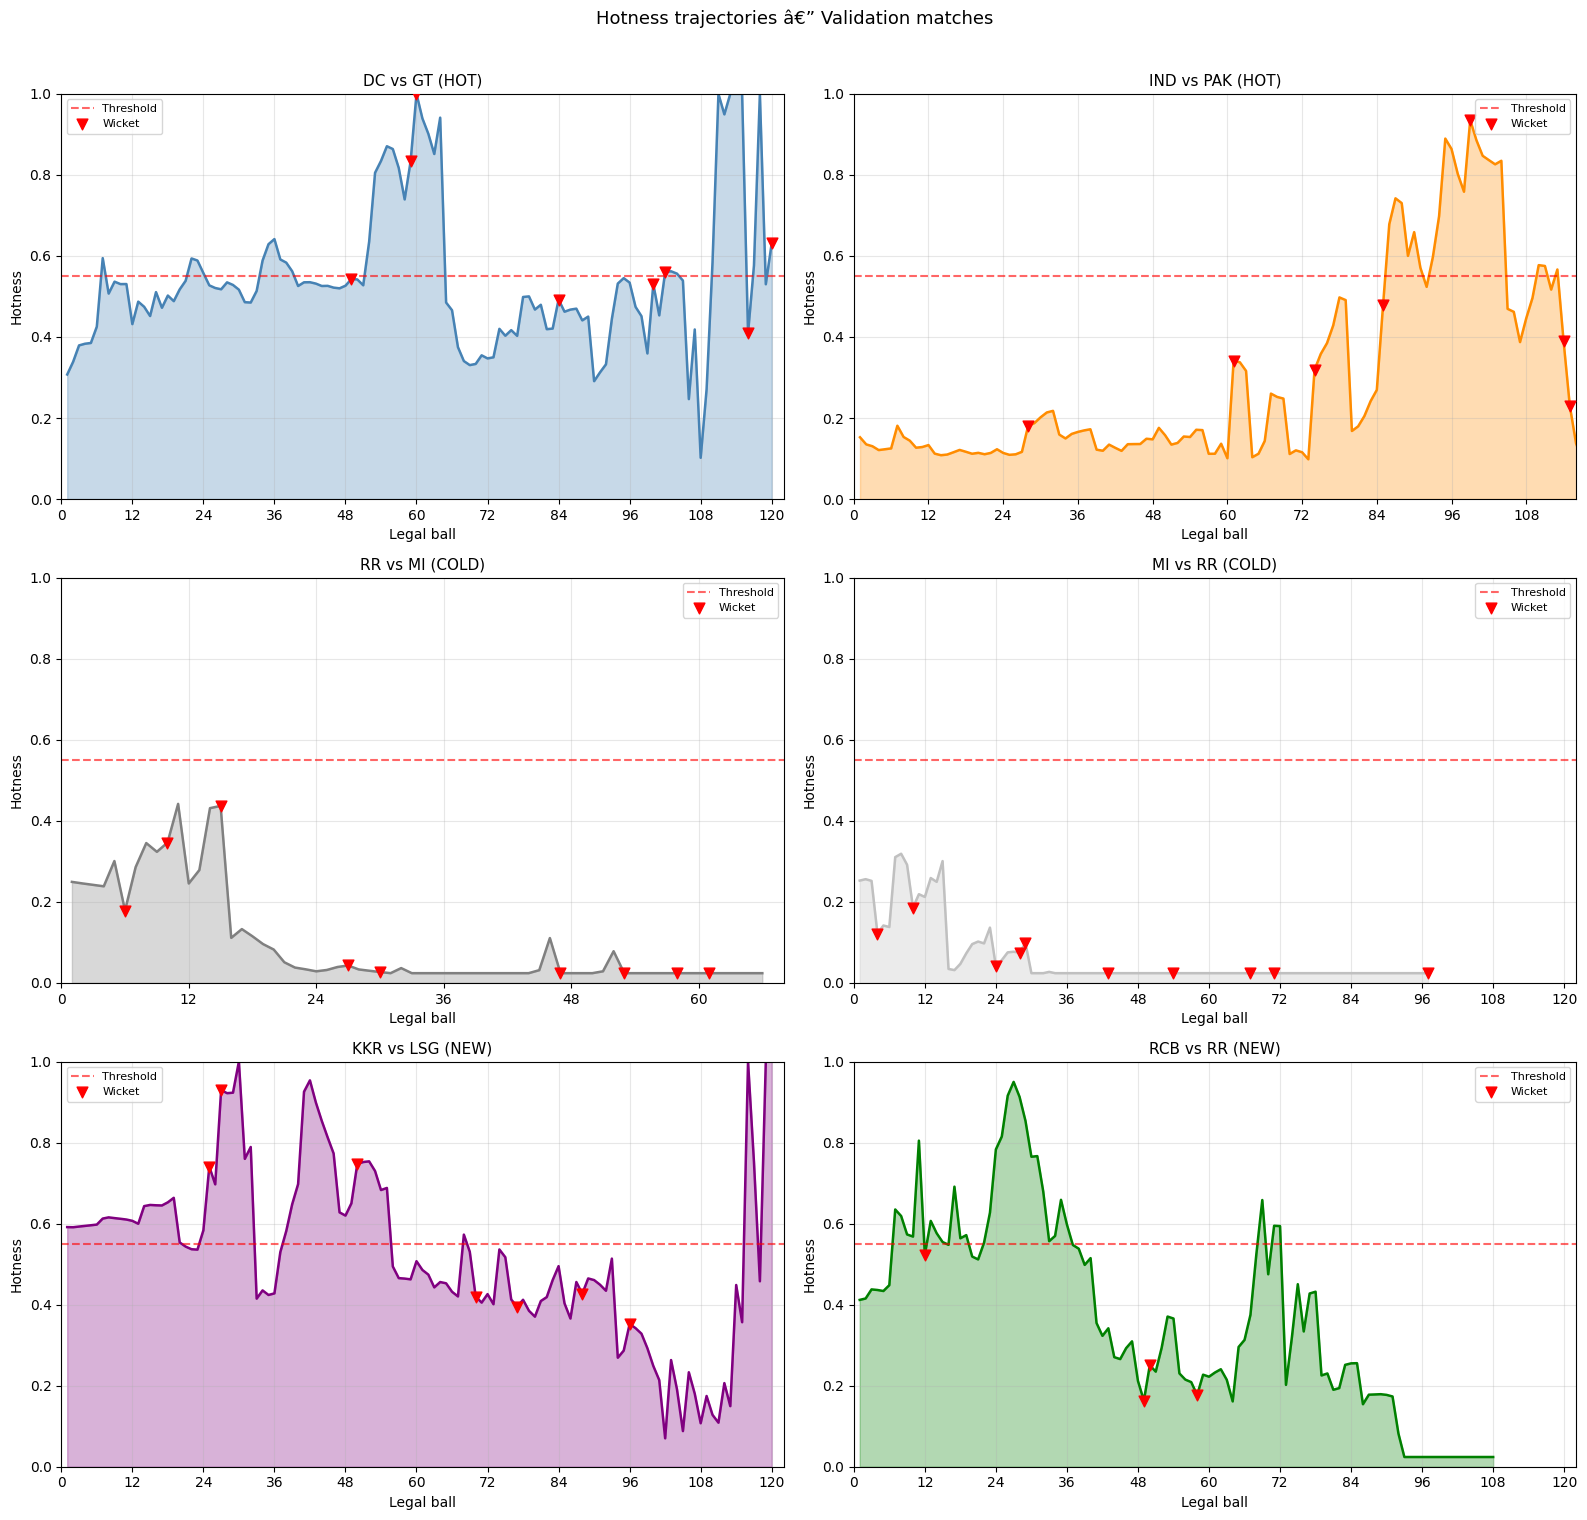

In [8]:
COLORS = {
    'DC vs GT (HOT)':   'steelblue',
    'IND vs PAK (HOT)': 'darkorange',
    'RR vs MI (COLD)':  'gray',
    'MI vs RR (COLD)':  'silver',
    'KKR vs LSG (NEW)': 'purple',
    'RCB vs RR (NEW)':  'green',
}

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

for ax, (label, chase) in zip(axes, val_results.items()):
    color = COLORS[label]
    ax.fill_between(chase['legal_ball'], chase['hotness'], alpha=0.3, color=color)
    ax.plot(chase['legal_ball'], chase['hotness'], color=color, linewidth=1.8)
    ax.axhline(0.55, color='red', linestyle='--', alpha=0.6, label='Threshold')

    # Mark wickets
    wk = chase[chase['is_wicket']]
    ax.scatter(wk['legal_ball'], wk['hotness'], color='red', zorder=5,
               s=60, marker='v', label='Wicket')

    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Legal ball')
    ax.set_ylabel('Hotness')
    ax.set_ylim(0, 1)
    ax.set_xlim(0, chase['total_balls'].iloc[0] + 2)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax.legend(fontsize=8)

plt.suptitle('Hotness trajectories â€” Validation matches', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'hotness_trajectories.png', dpi=150, bbox_inches='tight')
plt.show()

### Scatter: current hotness vs max hotness in next 6 balls

If there's a strong diagonal, current hotness is already a good predictor. If there's a cloud with outliers above the diagonal, those are the cases where drama spikes unexpectedly â€” exactly what we need the forecaster for.

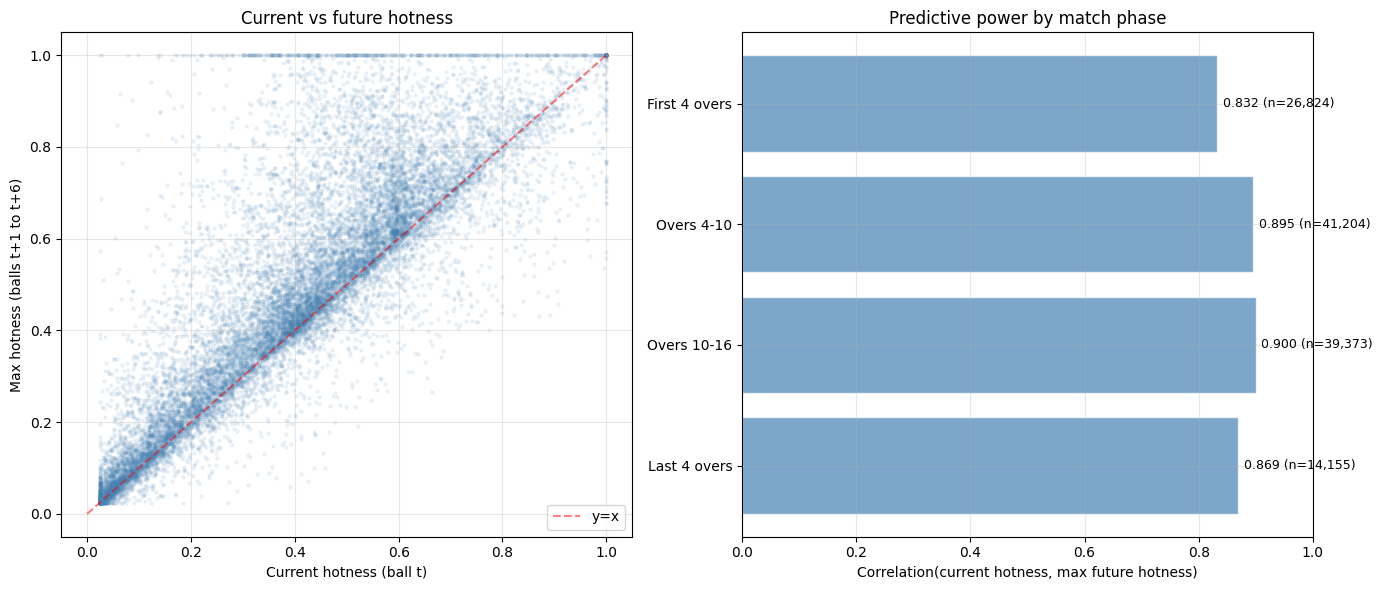

In [9]:
# Build scatter data from all chases
scatter_curr = []
scatter_fut  = []
scatter_br   = []

for chase in all_chases:
    h = chase['hotness'].values
    br = chase['balls_remaining'].values
    for t in range(len(h) - 6):
        scatter_curr.append(h[t])
        scatter_fut.append(h[t+1:t+7].max())
        scatter_br.append(br[t])

scatter_curr = np.array(scatter_curr)
scatter_fut  = np.array(scatter_fut)
scatter_br   = np.array(scatter_br)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full scatter (sampled for readability)
idx = np.random.choice(len(scatter_curr), size=min(20000, len(scatter_curr)), replace=False)
axes[0].scatter(scatter_curr[idx], scatter_fut[idx], alpha=0.08, s=5, c='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', alpha=0.5, label='y=x')
axes[0].set_xlabel('Current hotness (ball t)')
axes[0].set_ylabel('Max hotness (balls t+1 to t+6)')
axes[0].set_title('Current vs future hotness')
axes[0].legend()

# Correlation by balls_remaining bucket
br_bins = [(0, 24, 'Last 4 overs'), (24, 60, 'Overs 10-16'),
           (60, 96, 'Overs 4-10'), (96, 120, 'First 4 overs')]
corrs = []
for lo, hi, lbl in br_bins:
    mask = (scatter_br >= lo) & (scatter_br < hi)
    if mask.sum() > 100:
        r = np.corrcoef(scatter_curr[mask], scatter_fut[mask])[0, 1]
        corrs.append((lbl, r, mask.sum()))

labels_c, vals_c, counts_c = zip(*corrs)
bars = axes[1].barh(labels_c, vals_c, color='steelblue', alpha=0.7, edgecolor='white')
for bar, v, cnt in zip(bars, vals_c, counts_c):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{v:.3f} (n={cnt:,})', va='center', fontsize=9)
axes[1].set_xlabel('Correlation(current hotness, max future hotness)')
axes[1].set_title('Predictive power by match phase')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.savefig(FIG_DIR / 'current_vs_future_hotness.png', dpi=150, bbox_inches='tight')
plt.show()

### Heatmap: mean future hotness by (current hotness, balls remaining)

Shows where drama tends to emerge â€” should reveal that late-game + moderate hotness â†’ high future hotness.

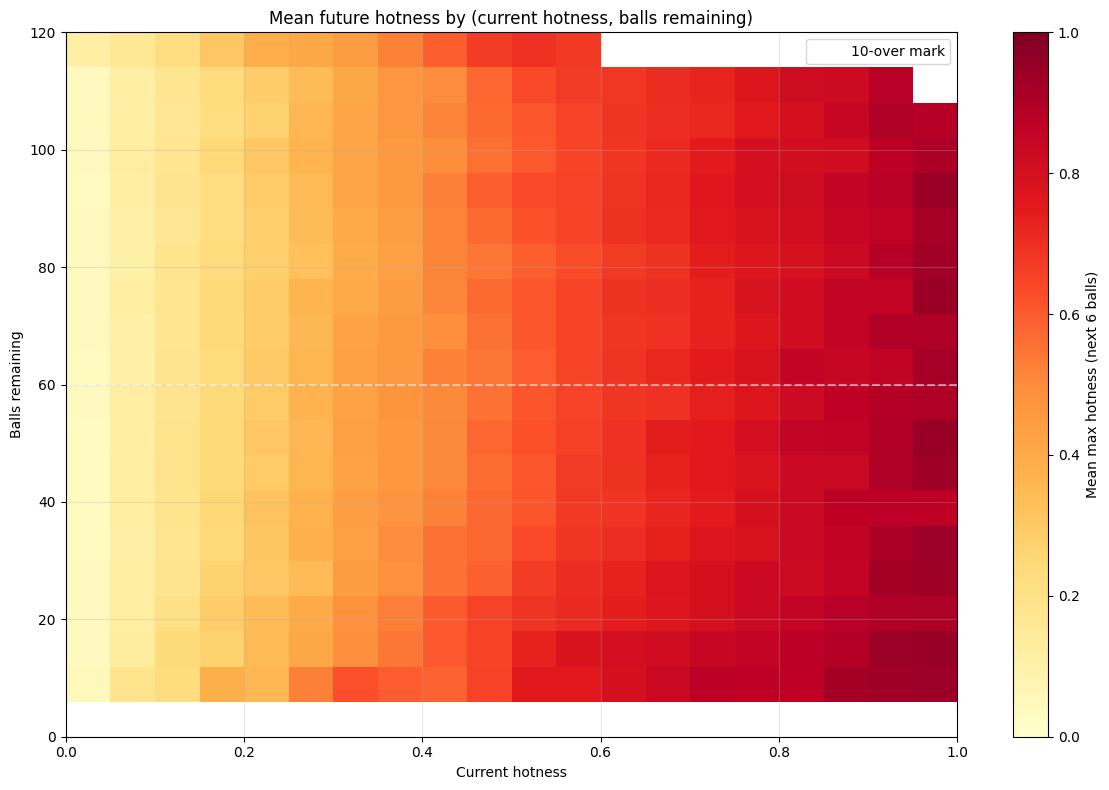

In [10]:
# Bin into grid
h_bins = np.linspace(0, 1, 21)       # 20 hotness bins
br_bins_grid = np.linspace(0, 120, 21)  # 20 balls-remaining bins

h_idx  = np.digitize(scatter_curr, h_bins) - 1
br_idx = np.digitize(scatter_br, br_bins_grid) - 1

grid = np.full((20, 20), np.nan)
count_grid = np.zeros((20, 20))

for i in range(len(scatter_curr)):
    hi, bi = h_idx[i], br_idx[i]
    if 0 <= hi < 20 and 0 <= bi < 20:
        if np.isnan(grid[bi, hi]):
            grid[bi, hi] = 0
        grid[bi, hi] += scatter_fut[i]
        count_grid[bi, hi] += 1

with np.errstate(invalid='ignore'):
    grid = grid / count_grid
grid[count_grid < 10] = np.nan  # suppress sparse bins

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(grid, origin='lower', aspect='auto', cmap='YlOrRd',
               extent=[0, 1, 0, 120], vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Mean max hotness (next 6 balls)')
ax.set_xlabel('Current hotness')
ax.set_ylabel('Balls remaining')
ax.set_title('Mean future hotness by (current hotness, balls remaining)')
ax.axhline(60, color='white', linestyle='--', alpha=0.5, label='10-over mark')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'future_hotness_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## Build training data for forecaster

For each ball `t` where `t >= 12` and `t + 6 <= len(chase)`:
- **Input**: `hotness[t-12:t]` (12 values) + `balls_remaining[t]`
- **Target**: `max(hotness[t:t+6])`

In [11]:
LOOKBACK = 12
HORIZON  = 6

X_windows = []
y_targets = []

for chase in all_chases:
    h  = chase['hotness'].values
    br = chase['balls_remaining'].values
    n  = len(h)

    for t in range(LOOKBACK, n - HORIZON + 1):
        window = h[t - LOOKBACK : t]           # 12 hotness values
        balls_rem = br[t] / 120.0              # normalised
        X_windows.append(np.append(window, balls_rem))  # 13 features
        y_targets.append(h[t : t + HORIZON].max())      # max hotness in next 6

X_all = np.array(X_windows, dtype=np.float32)
y_all = np.array(y_targets, dtype=np.float32)

print(f'Training samples: {len(X_all):,}')
print(f'Input shape: {X_all.shape}  (12 hotness lags + 1 balls_remaining)')
print(f'Target mean: {y_all.mean():.3f}, std: {y_all.std():.3f}')

Training samples: 108,808
Input shape: (108808, 13)  (12 hotness lags + 1 balls_remaining)
Target mean: 0.427, std: 0.287


### Target distribution

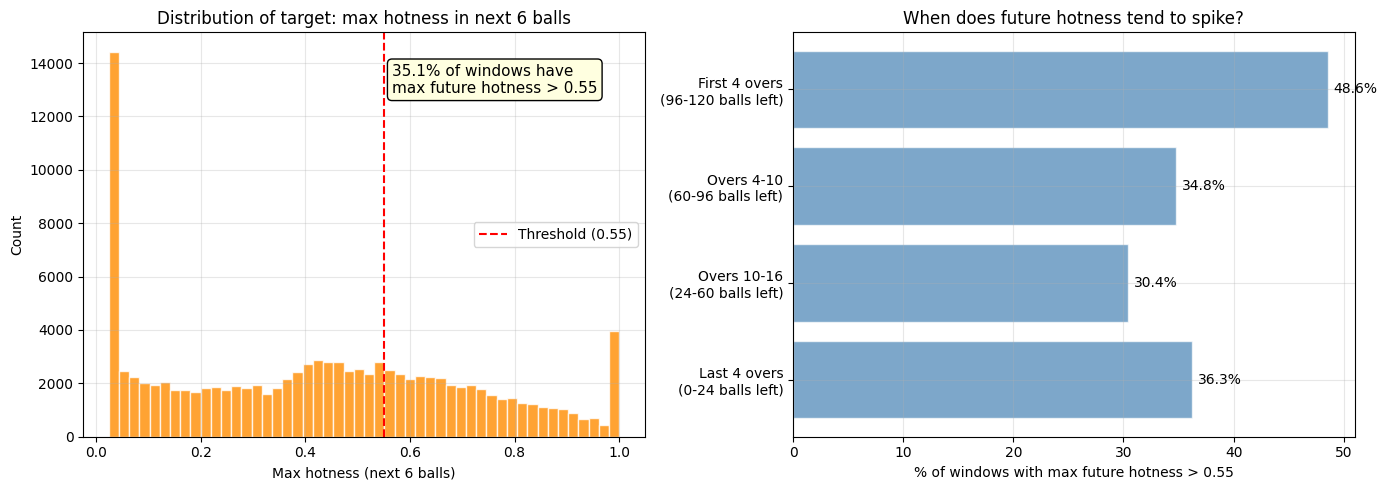

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_all, bins=50, color='darkorange', edgecolor='white', alpha=0.8)
axes[0].axvline(0.55, color='red', linestyle='--', label='Threshold (0.55)')
axes[0].set_title('Distribution of target: max hotness in next 6 balls')
axes[0].set_xlabel('Max hotness (next 6 balls)')
axes[0].set_ylabel('Count')
axes[0].legend()

pct = (y_all > 0.55).mean() * 100
axes[0].annotate(f'{pct:.1f}% of windows have\nmax future hotness > 0.55',
                 xy=(0.55, 0.85), xycoords='axes fraction', fontsize=11,
                 bbox=dict(boxstyle='round', facecolor='lightyellow'))

# Breakdown by match phase
br_norm = X_all[:, -1]  # last feature = balls_remaining / 120
phases = [
    ('Last 4 overs\n(0-24 balls left)',   (0, 0.20)),
    ('Overs 10-16\n(24-60 balls left)',    (0.20, 0.50)),
    ('Overs 4-10\n(60-96 balls left)',     (0.50, 0.80)),
    ('First 4 overs\n(96-120 balls left)', (0.80, 1.01)),
]
phase_pcts = []
phase_labels = []
for lbl, (lo, hi) in phases:
    mask = (br_norm >= lo) & (br_norm < hi)
    if mask.sum() > 0:
        phase_pcts.append((y_all[mask] > 0.55).mean() * 100)
        phase_labels.append(lbl)

axes[1].barh(phase_labels, phase_pcts, color='steelblue', alpha=0.7, edgecolor='white')
for i, v in enumerate(phase_pcts):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=10)
axes[1].set_xlabel('% of windows with max future hotness > 0.55')
axes[1].set_title('When does future hotness tend to spike?')

plt.tight_layout()
plt.savefig(FIG_DIR / 'target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Train autoregressive forecaster

Simple MLP: 13 inputs (12 hotness lags + balls_remaining) â†’ hidden layers â†’ 1 output (predicted max hotness next 6 balls).

In [13]:
class HotnessForecaster(nn.Module):
    def __init__(self, input_dim=13, hidden_dims=[64, 32]):
        super().__init__()
        layers = []
        prev = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(0.15)]
            prev = h
        layers += [nn.Linear(prev, 1), nn.Sigmoid()]  # output in [0, 1]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


# Normalise inputs (z-score the 12 hotness lags; balls_remaining already normalised)
X_train_mean = X_all[:, :LOOKBACK].mean()
X_train_std  = X_all[:, :LOOKBACK].std() + 1e-8

X_norm = X_all.copy()
X_norm[:, :LOOKBACK] = (X_norm[:, :LOOKBACK] - X_train_mean) / X_train_std
# balls_remaining is already in [0, 1]

# Train/val split
X_t = torch.tensor(X_norm)
y_t = torch.tensor(y_all)

dataset = TensorDataset(X_t, y_t)
n_val   = int(0.15 * len(dataset))
n_train = len(dataset) - n_val
train_ds, val_ds = random_split(dataset, [n_train, n_val])

train_loader = DataLoader(train_ds, batch_size=512, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=512)

forecaster = HotnessForecaster()
optimizer  = torch.optim.Adam(forecaster.parameters(), lr=1e-3)
loss_fn    = nn.MSELoss()

print(forecaster)
print(f'Parameters: {sum(p.numel() for p in forecaster.parameters()):,}')

HotnessForecaster(
  (net): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.15, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.15, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
    (7): Sigmoid()
  )
)
Parameters: 3,009


Epoch  10/60 â€” train MSE: 0.01563  val MSE: 0.01579
Epoch  20/60 â€” train MSE: 0.01529  val MSE: 0.01566
Epoch  30/60 â€” train MSE: 0.01511  val MSE: 0.01548
Epoch  40/60 â€” train MSE: 0.01500  val MSE: 0.01545
Epoch  50/60 â€” train MSE: 0.01489  val MSE: 0.01536
Epoch  60/60 â€” train MSE: 0.01488  val MSE: 0.01534


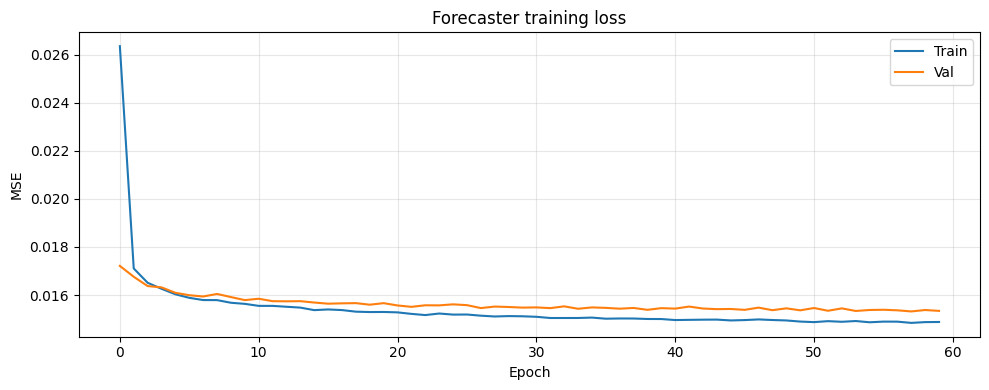

In [14]:
EPOCHS = 60
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    forecaster.train()
    batch_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        pred = forecaster(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        optimizer.step()
        batch_losses.append(loss.item())
    train_losses.append(np.mean(batch_losses))

    forecaster.eval()
    with torch.no_grad():
        vl = np.mean([loss_fn(forecaster(xb), yb).item() for xb, yb in val_loader])
    val_losses.append(vl)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} â€” train MSE: {train_losses[-1]:.5f}  '
              f'val MSE: {val_losses[-1]:.5f}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train')
ax.plot(val_losses, label='Val')
ax.set_title('Forecaster training loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / 'training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## Evaluate on validation matches

For each of the 6 matches, compute:
1. Actual hotness (from nb06)
2. Forecasted max hotness (next 6 balls) at each ball
3. Compare: when would the forecaster have triggered a notification?

In [15]:
def forecast_match(chase):
    """Run forecaster on a chase DataFrame. Returns forecast array (NaN for first 12 balls)."""
    h  = chase['hotness'].values
    br = chase['balls_remaining'].values
    n  = len(h)
    forecasts = np.full(n, np.nan)

    forecaster.eval()
    for t in range(LOOKBACK, n):
        window = h[t - LOOKBACK : t]
        balls_rem = br[t] / 120.0
        x = np.append(window, balls_rem).astype(np.float32)
        x[:LOOKBACK] = (x[:LOOKBACK] - X_train_mean) / X_train_std
        with torch.no_grad():
            forecasts[t] = forecaster(torch.tensor(x).unsqueeze(0)).item()

    return forecasts


for label, chase in val_results.items():
    chase['forecast'] = forecast_match(chase)
    print(f'{label}: forecast computed ({(~np.isnan(chase["forecast"].values)).sum()} balls)')

DC vs GT (HOT): forecast computed (108 balls)
IND vs PAK (HOT): forecast computed (108 balls)
RR vs MI (COLD): forecast computed (54 balls)
MI vs RR (COLD): forecast computed (85 balls)
KKR vs LSG (NEW): forecast computed (108 balls)
RCB vs RR (NEW): forecast computed (96 balls)


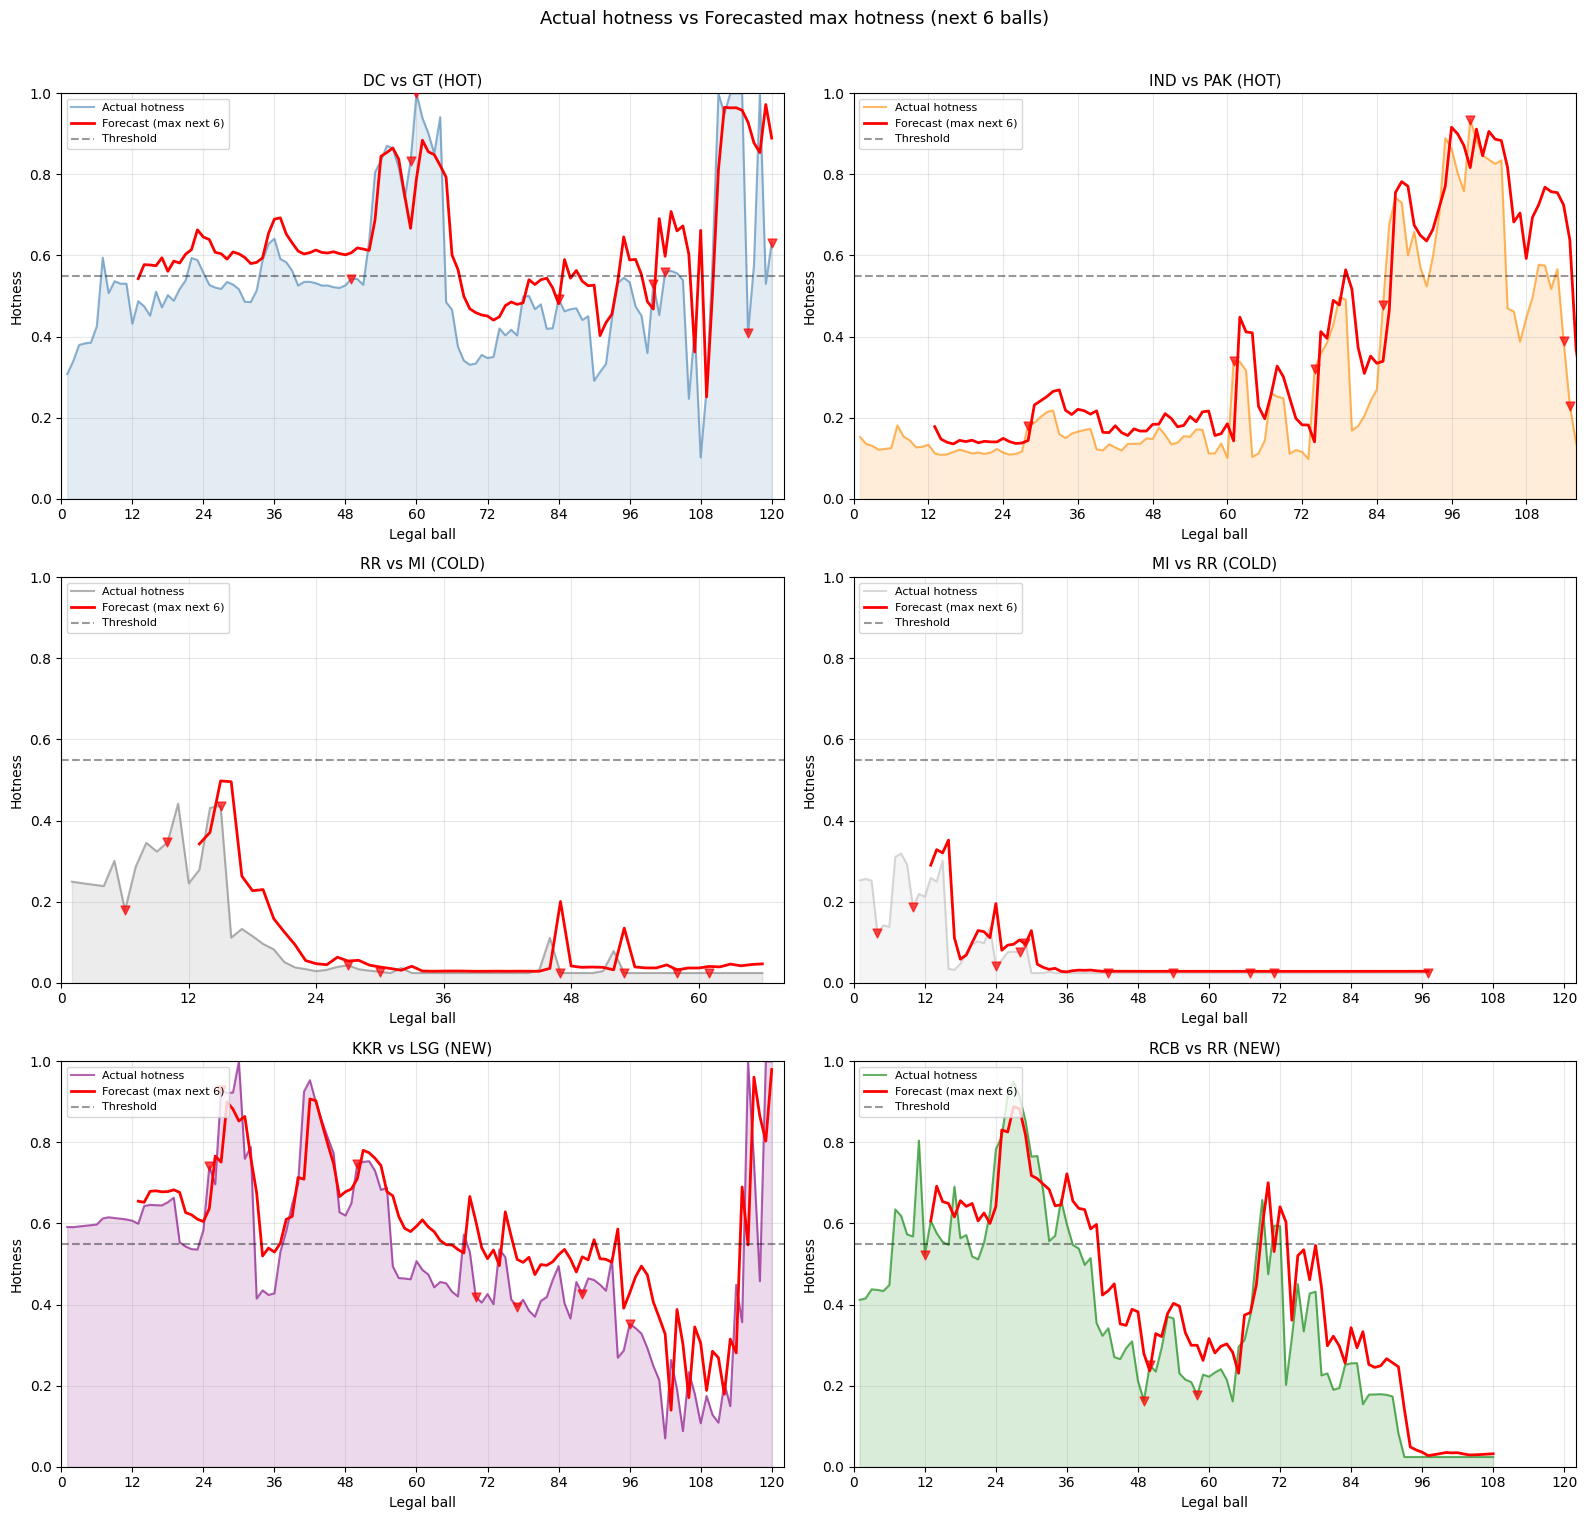

In [16]:
fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

for ax, (label, chase) in zip(axes, val_results.items()):
    color = COLORS[label]
    balls = chase['legal_ball'].values

    # Actual hotness
    ax.plot(balls, chase['hotness'], color=color, linewidth=1.5,
            alpha=0.6, label='Actual hotness')
    ax.fill_between(balls, chase['hotness'], alpha=0.15, color=color)

    # Forecast
    ax.plot(balls, chase['forecast'], color='red', linewidth=2,
            label='Forecast (max next 6)')

    # Threshold
    ax.axhline(0.55, color='black', linestyle='--', alpha=0.4, label='Threshold')

    # Mark wickets
    wk = chase[chase['is_wicket']]
    ax.scatter(wk['legal_ball'], wk['hotness'], color='red', zorder=5,
               s=40, marker='v', alpha=0.7)

    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Legal ball')
    ax.set_ylabel('Hotness')
    ax.set_ylim(0, 1)
    ax.set_xlim(0, chase['total_balls'].iloc[0] + 2)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(12))
    ax.legend(fontsize=8, loc='upper left')

plt.suptitle('Actual hotness vs Forecasted max hotness (next 6 balls)',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'forecast_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()

## When would the forecaster have fired?

Find the first ball where `forecast >= threshold` (no sustained window needed â€” the forecast itself is a forward-looking prediction).

In [17]:
FORECAST_THRESHOLD = 0.55

print(f'Forecast notification threshold: {FORECAST_THRESHOLD}')
print()

for label, chase in val_results.items():
    tag = 'HOT' if 'HOT' in label else ('COLD' if 'COLD' in label else 'NEW')
    fc = chase['forecast'].values
    total = int(chase['total_balls'].iloc[0])

    # First ball where forecast crosses threshold
    above = np.where(fc >= FORECAST_THRESHOLD)[0]
    if len(above) > 0:
        idx = above[0]
        row = chase.iloc[idx]
        ball = int(row['legal_ball'])
        over = (ball - 1) // 6 + 1
        br = int(row['balls_remaining'])
        print(f'[{tag}] {label}:')
        print(f'  Forecast fires: ball {ball} (over {over}), {br} balls left')
        print(f'  Score: {int(row["score"])}/{int(row["wickets_fallen"])}, '
              f'need {int(row["runs_needed"])}')
        print(f'  Actual hotness: {row["hotness"]:.2f}, '
              f'forecast: {row["forecast"]:.2f}')
    else:
        print(f'[{tag}] {label}: forecast never crosses threshold')
    print()

Forecast notification threshold: 0.55

[HOT] DC vs GT (HOT):
  Forecast fires: ball 14 (over 3), 106 balls left
  Score: 22/0, need 189
  Actual hotness: 0.47, forecast: 0.58

[HOT] IND vs PAK (HOT):
  Forecast fires: ball 79 (over 14), 35 balls left
  Score: 74/3, need 46
  Actual hotness: 0.49, forecast: 0.56

[COLD] RR vs MI (COLD): forecast never crosses threshold

[COLD] MI vs RR (COLD): forecast never crosses threshold

[NEW] KKR vs LSG (NEW):
  Forecast fires: ball 13 (over 3), 107 balls left
  Score: 17/0, need 165
  Actual hotness: 0.60, forecast: 0.66

[NEW] RCB vs RR (NEW):
  Forecast fires: ball 13 (over 3), 107 balls left
  Score: 21/1, need 181
  Actual hotness: 0.61, forecast: 0.61



## Deep dive: KKR vs LSG timing

The critical question â€” does the forecaster predict drama *before* ball 114 (when the actual hotness fires)?

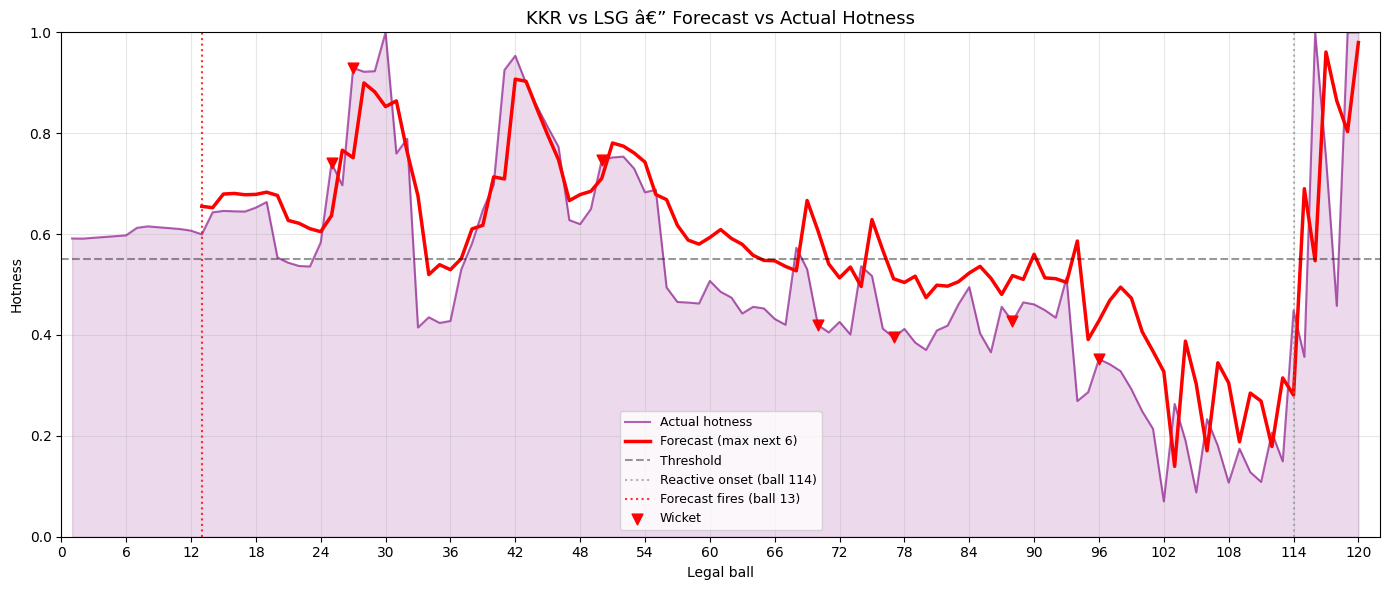


Over-by-over from over 14:
 Ball    Score  Need     WP    Hot   Fcst   W
------------------------------------------
   79  108/5    74 0.28  0.38  0.52  
   80  112/5    70 0.30  0.37  0.47  
   81  112/5    70 0.29  0.41  0.50  
   82  114/5    68 0.29  0.42  0.50  
   83  118/5    64 0.31  0.46  0.51  
   84  119/5    63 0.31  0.49  0.52  
   85  119/5    63 0.30  0.40  0.54  
   86  119/5    63 0.29  0.37  0.51  
   87  125/5    57 0.32  0.46  0.48  
   88  125/6    57 0.20  0.43  0.52  W
   89  126/6    56 0.20  0.46  0.51  
   90  127/6    55 0.20  0.46  0.56  
   91  127/6    55 0.19  0.45  0.51  
   92  127/6    55 0.18  0.43  0.51  
   93  127/6    55 0.16  0.51  0.50  
   94  128/6    54 0.16  0.27  0.59  
   95  128/6    54 0.14  0.29  0.39  
   96  128/7    54 0.05  0.35  0.43  W
   97  128/7    54 0.04  0.34  0.47  
   98  128/7    54 0.03  0.33  0.49  
   99  132/7    50 0.04  0.29  0.47  
  100  138/7    44 0.08  0.25  0.41  
  101  139/7    43 0.07  0.21  0.37  
  102  

In [18]:
kkr = val_results['KKR vs LSG (NEW)']

fig, ax = plt.subplots(figsize=(14, 6))

balls = kkr['legal_ball'].values
ax.plot(balls, kkr['hotness'], color='purple', linewidth=1.5,
        alpha=0.6, label='Actual hotness')
ax.fill_between(balls, kkr['hotness'], alpha=0.15, color='purple')
ax.plot(balls, kkr['forecast'], color='red', linewidth=2.5,
        label='Forecast (max next 6)')
ax.axhline(0.55, color='black', linestyle='--', alpha=0.4, label='Threshold')

# Mark where reactive detector fires (ball 114)
ax.axvline(114, color='gray', linestyle=':', alpha=0.6, label='Reactive onset (ball 114)')

# Mark where forecaster fires
fc = kkr['forecast'].values
above = np.where(fc >= FORECAST_THRESHOLD)[0]
if len(above) > 0:
    fire_ball = int(kkr.iloc[above[0]]['legal_ball'])
    ax.axvline(fire_ball, color='red', linestyle=':', alpha=0.8,
               label=f'Forecast fires (ball {fire_ball})')

# Mark wickets
wk = kkr[kkr['is_wicket']]
ax.scatter(wk['legal_ball'], wk['hotness'], color='red', zorder=5,
           s=60, marker='v', label='Wicket')

ax.set_title('KKR vs LSG â€” Forecast vs Actual Hotness', fontsize=13)
ax.set_xlabel('Legal ball')
ax.set_ylabel('Hotness')
ax.set_ylim(0, 1)
ax.set_xlim(0, 122)
ax.xaxis.set_major_locator(ticker.MultipleLocator(6))
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / 'kkr_lsg_forecast_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()

# Print over-by-over from over 14
print('\nOver-by-over from over 14:')
print(f'{"Ball":>5} {"Score":>8} {"Need":>5} {"WP":>6} {"Hot":>6} {"Fcst":>6} {"W":>3}')
print('-' * 42)
for _, r in kkr[kkr['legal_ball'] >= 79].iterrows():
    w = 'W' if r['is_wicket'] else ''
    fc_val = f"{r['forecast']:.2f}" if not np.isnan(r['forecast']) else '  -'
    print(f"{int(r['legal_ball']):>5} {int(r['score']):>4}/{int(r['wickets_fallen'])} "
          f"{int(r['runs_needed']):>5} {r['win_prob']:.2f}  {r['hotness']:.2f}  "
          f"{fc_val}  {w}")

## Summary table

In [19]:
print(f'{"Match":<25} {"Tag":<5} {"Reactive":>10} {"Forecast":>10} {"Lead":>8} {"MaxHot":>8}')
print('-' * 70)

for label, chase in val_results.items():
    tag = 'HOT' if 'HOT' in label else ('COLD' if 'COLD' in label else 'NEW')
    fc = chase['forecast'].values
    h  = chase['hotness'].values
    total = int(chase['total_balls'].iloc[0])

    # Reactive onset (sustained 6 balls)
    hot_mask = h >= 0.55
    reactive_ball = None
    for i in range(len(hot_mask) - 6):
        if hot_mask[i:i+6].all():
            reactive_ball = int(chase.iloc[i]['legal_ball'])
            break

    # Forecast onset
    above = np.where(fc >= FORECAST_THRESHOLD)[0]
    forecast_ball = int(chase.iloc[above[0]]['legal_ball']) if len(above) > 0 else None

    r_str = f'ball {reactive_ball}' if reactive_ball else 'never'
    f_str = f'ball {forecast_ball}' if forecast_ball else 'never'

    if reactive_ball and forecast_ball:
        lead = reactive_ball - forecast_ball
        lead_str = f'+{lead} balls' if lead > 0 else f'{lead} balls'
    else:
        lead_str = '-'

    print(f'{label:<25} {tag:<5} {r_str:>10} {f_str:>10} {lead_str:>8} '
          f'{chase["hotness"].max():>8.3f}')

Match                     Tag     Reactive   Forecast     Lead   MaxHot
----------------------------------------------------------------------
DC vs GT (HOT)            HOT      ball 34    ball 14 +20 balls    1.000
IND vs PAK (HOT)          HOT      ball 86    ball 79 +7 balls    0.935
RR vs MI (COLD)           COLD       never      never        -    0.442
MI vs RR (COLD)           COLD       never      never        -    0.319
KKR vs LSG (NEW)          NEW       ball 1    ball 13 -12 balls    1.000
RCB vs RR (NEW)           NEW      ball 22    ball 13 +9 balls    0.950


## Save forecaster model

In [20]:
forecast_ckpt = {
    'model_state_dict': forecaster.state_dict(),
    'input_dim': 13,
    'hidden_dims': [64, 32],
    'lookback': LOOKBACK,
    'horizon': HORIZON,
    'X_train_mean': X_train_mean,
    'X_train_std': X_train_std,
}

torch.save(forecast_ckpt, MODELS_DIR / 'hotness_forecaster.pt')
print('Saved:', MODELS_DIR / 'hotness_forecaster.pt')
print('Checkpoint keys:', list(forecast_ckpt.keys()))

Saved: ..\models\hotness_forecaster.pt
Checkpoint keys: ['model_state_dict', 'input_dim', 'hidden_dims', 'lookback', 'horizon', 'X_train_mean', 'X_train_std']
